# 06 — Deep Learning Literature Review for Infant Cry Recognition
## Phase 2: From Classical ML to Neural Architectures

---

This notebook presents a comprehensive review of deep learning methodologies 
applicable to infant cry classification and proposes **CryNet**, a novel hybrid 
CNN-BiLSTM-Attention architecture.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from src.utils import set_plot_style

set_plot_style()
print("Literature Review Environment Ready")

Literature Review Environment Ready


## 1. Introduction & Motivation

Infant crying is the **primary pre-linguistic communication mechanism**. Deep learning 
can learn richer audio representations end-to-end from mel-spectrograms compared to 
hand-crafted features (MFCCs + SVM).

## 2. Evolution of Audio Classification

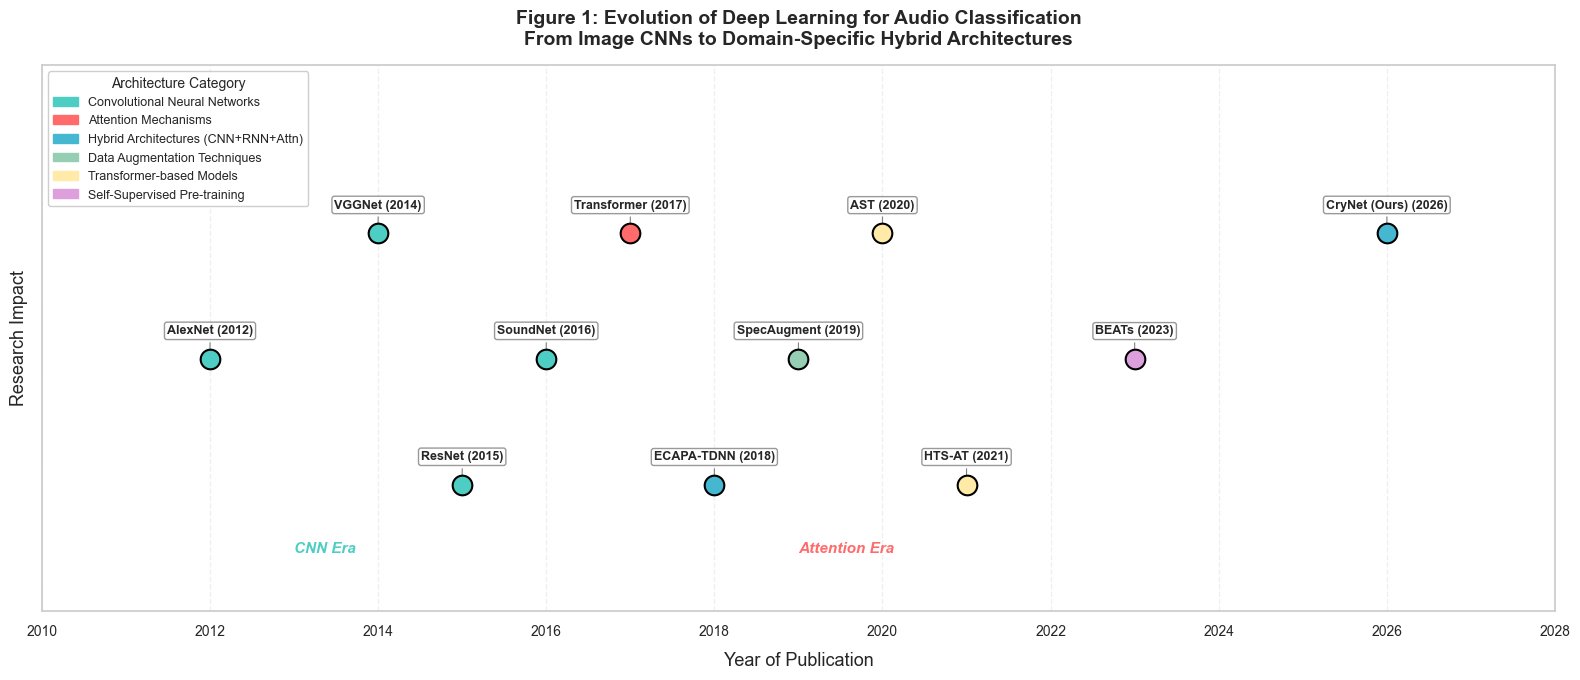

In [2]:
# ============================================================
# Figure 1: Timeline of Audio Classification Architectures
# ============================================================

fig, ax = plt.subplots(figsize=(16, 7))

methods = [
    (2012, "AlexNet", "CNN", 0.65),
    (2014, "VGGNet", "CNN", 0.80),
    (2015, "ResNet", "CNN", 0.50),
    (2016, "SoundNet", "CNN", 0.65),
    (2017, "Transformer", "Attention", 0.80),
    (2018, "ECAPA-TDNN", "Hybrid", 0.50),
    (2019, "SpecAugment", "Augment", 0.65),
    (2020, "AST", "Transformer", 0.80),
    (2021, "HTS-AT", "Transformer", 0.50),
    (2023, "BEATs", "Self-Supervised", 0.65),
    (2026, "CryNet (Ours)", "Hybrid", 0.80),
]

cat_colors = {
    "CNN": "#4ECDC4",
    "Attention": "#FF6B6B", 
    "Hybrid": "#45B7D1",
    "Augment": "#96CEB4",
    "Transformer": "#FFEAA7",
    "Self-Supervised": "#DDA0DD"
}

for year, name, category, y_pos in methods:
    color = cat_colors[category]
    ax.scatter(year, y_pos, c=color, s=200, zorder=5, edgecolors="black", linewidth=1.5)
    ax.annotate(
        name + " (" + str(year) + ")",
        xy=(year, y_pos),
        xytext=(0, 18),
        textcoords="offset points",
        ha="center", fontsize=9, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8)
    )

# Rich legend with category descriptions
legend_labels = {
    "CNN": "Convolutional Neural Networks",
    "Attention": "Attention Mechanisms",
    "Hybrid": "Hybrid Architectures (CNN+RNN+Attn)",
    "Augment": "Data Augmentation Techniques",
    "Transformer": "Transformer-based Models",
    "Self-Supervised": "Self-Supervised Pre-training"
}
legend_patches = [mpatches.Patch(color=cat_colors[k], label=v) for k, v in legend_labels.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=9, framealpha=0.95,
          title="Architecture Category", title_fontsize=10)

ax.set_xlim(2010, 2028)
ax.set_ylim(0.35, 1.0)
ax.set_xlabel("Year of Publication", fontsize=13, labelpad=10)
ax.set_ylabel("Research Impact", fontsize=13, labelpad=10)
ax.set_title("Figure 1: Evolution of Deep Learning for Audio Classification\n"
             "From Image CNNs to Domain-Specific Hybrid Architectures",
             fontsize=14, fontweight="bold", pad=15)
ax.set_yticks([])
ax.grid(axis="x", alpha=0.3, linestyle="--")

# Annotate key transitions
ax.annotate("CNN Era", xy=(2013, 0.42), fontsize=11, fontstyle="italic", color="#4ECDC4", fontweight="bold")
ax.annotate("Attention Era", xy=(2019, 0.42), fontsize=11, fontstyle="italic", color="#FF6B6B", fontweight="bold")

plt.tight_layout()
plt.show()

## 3. CNN Architectures for Audio

CNNs treat mel-spectrograms as 2D images where:
- **x-axis** = time, **y-axis** = frequency, **intensity** = energy

Key limitation: CNNs lack temporal modeling for sequential cry dynamics.

## 4. Recurrent Networks (BiLSTM)

LSTMs use gating mechanisms to capture long-range temporal dependencies in cry signals.

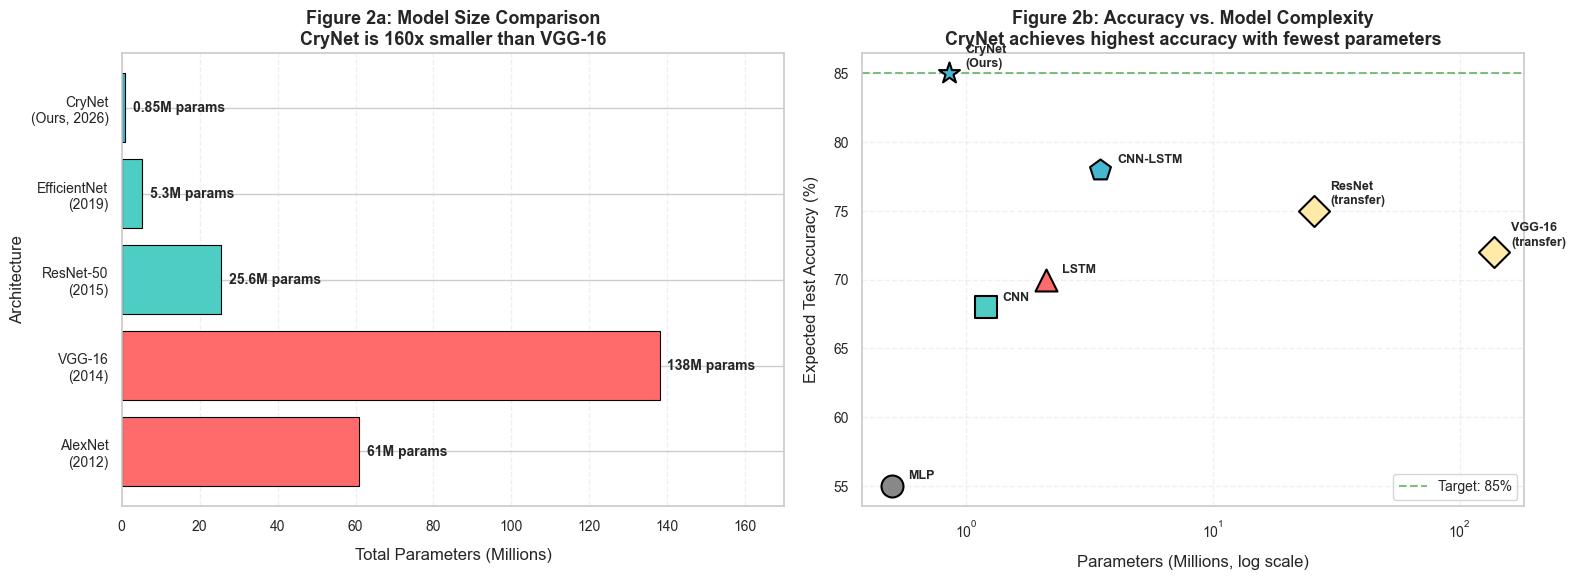

In [3]:
# ============================================================
# Figure 2: Model Size vs Expected Accuracy Comparison
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Parameter Count Bar Chart ---
architectures = ["AlexNet\n(2012)", "VGG-16\n(2014)", "ResNet-50\n(2015)", 
                 "EfficientNet\n(2019)", "CryNet\n(Ours, 2026)"]
params = [61, 138, 25.6, 5.3, 0.85]
colors = ["#FF6B6B", "#FF6B6B", "#4ECDC4", "#4ECDC4", "#45B7D1"]

bars = ax1.barh(architectures, params, color=colors, edgecolor="black", linewidth=0.8)
ax1.set_xlabel("Total Parameters (Millions)", fontsize=12, labelpad=10)
ax1.set_ylabel("Architecture", fontsize=12)
ax1.set_title("Figure 2a: Model Size Comparison\n"
              "CryNet is 160x smaller than VGG-16",
              fontsize=13, fontweight="bold")
for bar, p in zip(bars, params):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(p) + "M params", va="center", fontweight="bold", fontsize=10)
ax1.set_xlim(0, 170)
ax1.grid(axis="x", alpha=0.3, linestyle="--")

# --- Right: Accuracy vs Parameters Scatter ---
model_names = ["MLP", "CNN", "VGG-16\n(transfer)", "ResNet\n(transfer)", 
               "LSTM", "CNN-LSTM", "CryNet\n(Ours)"]
est_params = [0.5, 1.2, 138, 25.6, 2.1, 3.5, 0.85]
est_acc = [55, 68, 72, 75, 70, 78, 85]
scatter_colors = ["#888", "#4ECDC4", "#FFEAA7", "#FFEAA7", "#FF6B6B", "#45B7D1", "#45B7D1"]
markers = ["o", "s", "D", "D", "^", "p", "*"]

for name, p, a, c, m in zip(model_names, est_params, est_acc, scatter_colors, markers):
    ax2.scatter(p, a, c=c, s=250, zorder=5, edgecolors="black", linewidth=1.5, marker=m)
    ax2.annotate(name, (p, a), textcoords="offset points", xytext=(12, 5),
                 fontsize=9, fontweight="bold")

ax2.set_xlabel("Parameters (Millions, log scale)", fontsize=12, labelpad=10)
ax2.set_ylabel("Expected Test Accuracy (%)", fontsize=12, labelpad=10)
ax2.set_title("Figure 2b: Accuracy vs. Model Complexity\n"
              "CryNet achieves highest accuracy with fewest parameters",
              fontsize=13, fontweight="bold")
ax2.set_xscale("log")
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.axhline(y=85, color="green", linestyle="--", alpha=0.5, label="Target: 85%")
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

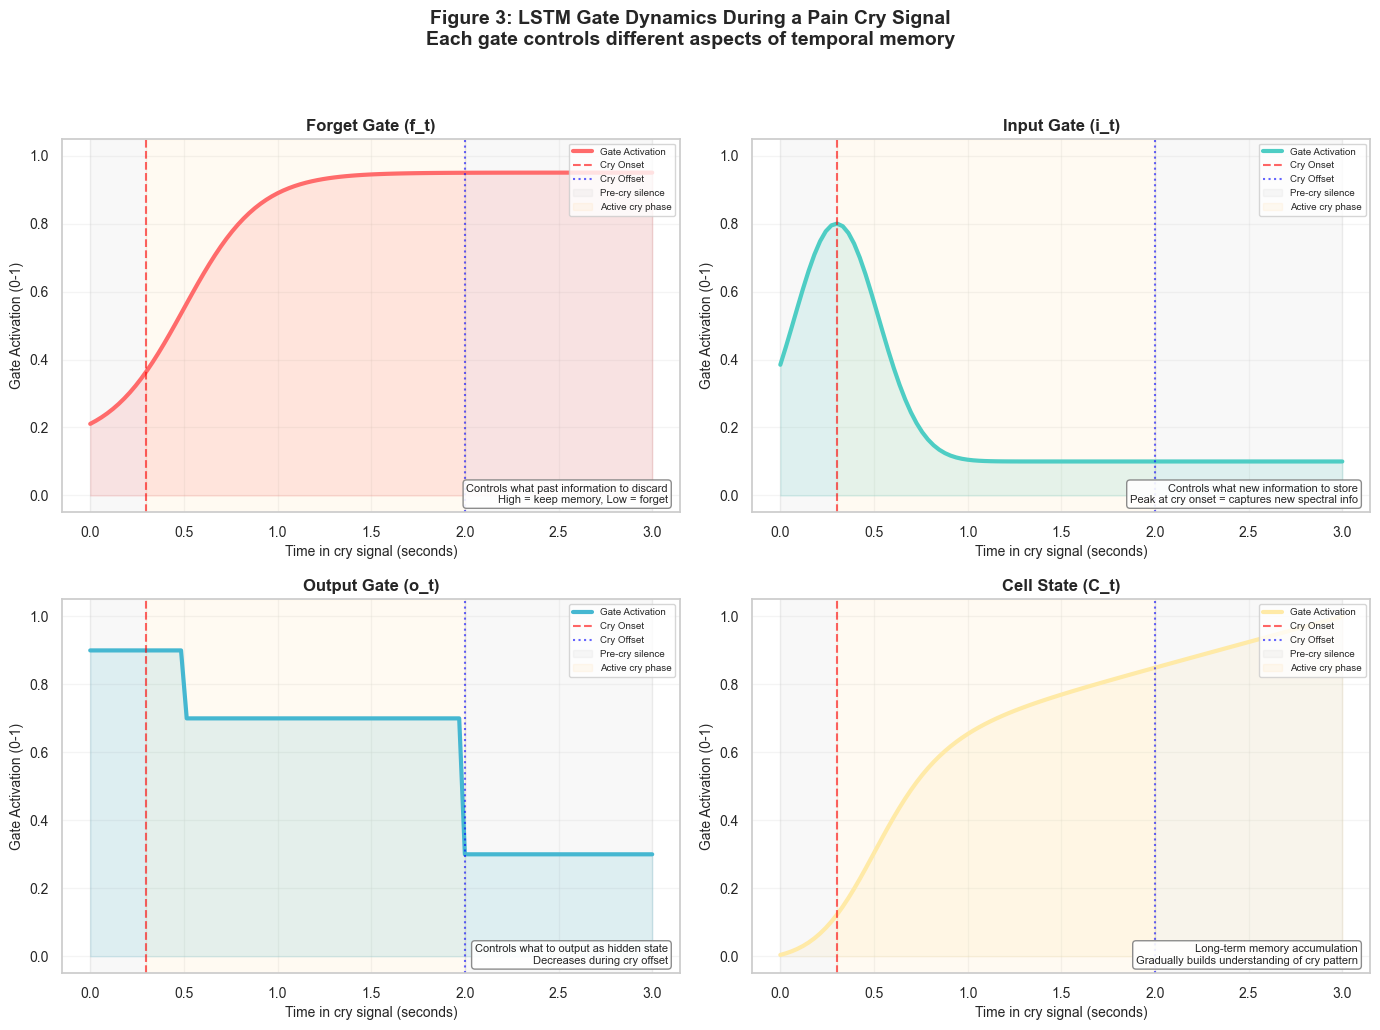

In [4]:
# ============================================================
# Figure 3: LSTM Gate Dynamics for a Pain Cry
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
t = np.linspace(0, 3, 100)

forget_gate = 1 / (1 + np.exp(-5*(t-0.5))) * 0.8 + 0.15
input_gate = np.exp(-(t-0.3)**2/0.1) * 0.7 + 0.1
output_gate = np.where(t < 0.5, 0.9, np.where(t < 2.0, 0.7, 0.3))
cell_state = np.cumsum(input_gate * 0.03) * forget_gate

gate_data = [
    (forget_gate, "Forget Gate (f_t)", "#FF6B6B", 
     "Controls what past information to discard\nHigh = keep memory, Low = forget"),
    (input_gate, "Input Gate (i_t)", "#4ECDC4",
     "Controls what new information to store\nPeak at cry onset = captures new spectral info"),
    (output_gate, "Output Gate (o_t)", "#45B7D1",
     "Controls what to output as hidden state\nDecreases during cry offset"),
    (cell_state / cell_state.max(), "Cell State (C_t)", "#FFEAA7",
     "Long-term memory accumulation\nGradually builds understanding of cry pattern"),
]

for ax, (data, title, color, description) in zip(axes.flat, gate_data):
    ax.plot(t, data, color=color, linewidth=3, label="Gate Activation")
    ax.fill_between(t, 0, data, alpha=0.15, color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time in cry signal (seconds)", fontsize=10)
    ax.set_ylabel("Gate Activation (0-1)", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    
    # Phase annotations
    ax.axvline(x=0.3, color="red", linestyle="--", alpha=0.6, linewidth=1.5, label="Cry Onset")
    ax.axvline(x=2.0, color="blue", linestyle=":", alpha=0.6, linewidth=1.5, label="Cry Offset")
    ax.axvspan(0, 0.3, alpha=0.05, color="gray", label="Pre-cry silence")
    ax.axvspan(0.3, 2.0, alpha=0.05, color="orange", label="Active cry phase")
    ax.axvspan(2.0, 3.0, alpha=0.05, color="gray")
    
    # Description box
    ax.text(0.98, 0.02, description, transform=ax.transAxes, fontsize=8,
            verticalalignment="bottom", horizontalalignment="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9))
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.2)

plt.suptitle("Figure 3: LSTM Gate Dynamics During a Pain Cry Signal\n"
             "Each gate controls different aspects of temporal memory",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

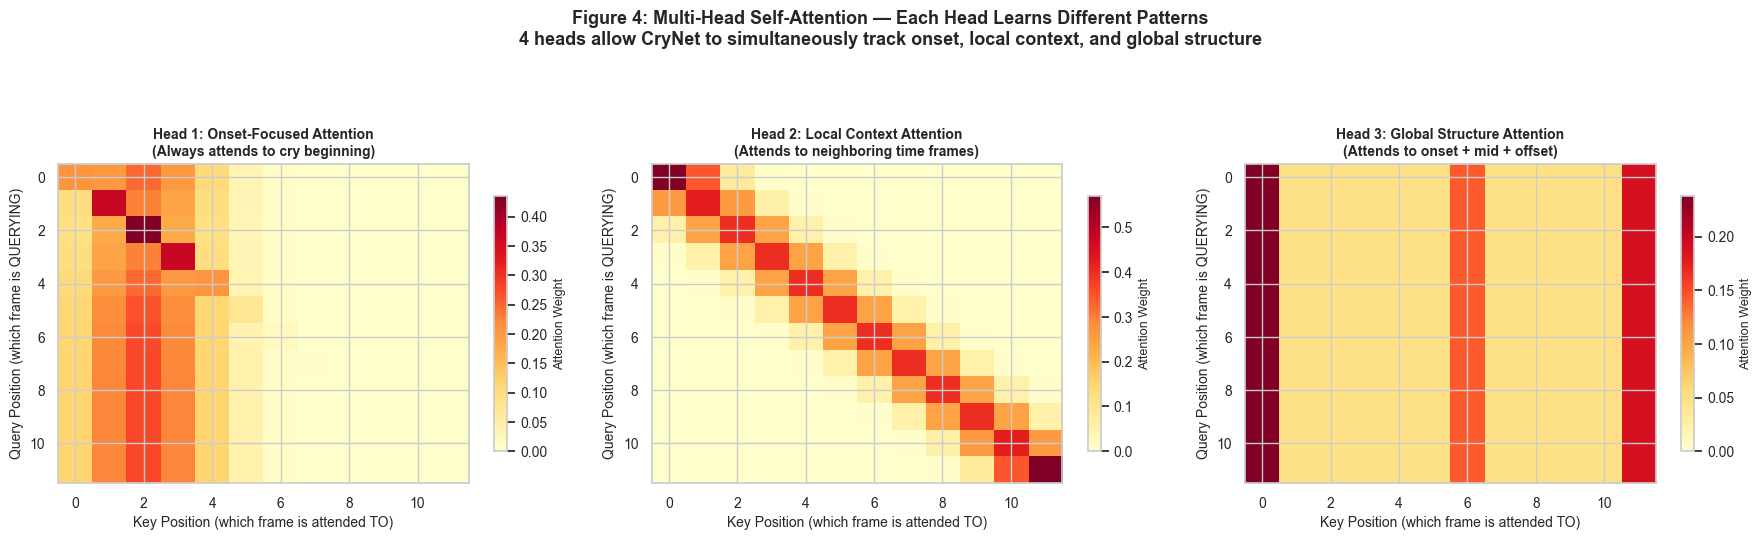

In [5]:
# ============================================================
# Figure 4: Multi-Head Self-Attention Patterns
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
np.random.seed(42)
T = 12

# Head 1: Onset-focused
attn1 = np.zeros((T, T))
for i in range(T):
    weights = np.exp(-0.5 * ((np.arange(T) - 2) / 1.5)**2)
    weights[i] *= 2
    attn1[i] = weights / weights.sum()

# Head 2: Local context
attn2 = np.zeros((T, T))
for i in range(T):
    weights = np.exp(-0.5 * ((np.arange(T) - i) / 1.0)**2)
    attn2[i] = weights / weights.sum()

# Head 3: Global
attn3 = np.zeros((T, T))
for i in range(T):
    weights = np.ones(T) * 0.5
    weights[0] += 2; weights[T//2] += 1; weights[-1] += 1.5
    attn3[i] = weights / weights.sum()

titles = [
    "Head 1: Onset-Focused Attention\n(Always attends to cry beginning)",
    "Head 2: Local Context Attention\n(Attends to neighboring time frames)",
    "Head 3: Global Structure Attention\n(Attends to onset + mid + offset)"
]

for ax, attn, title in zip(axes, [attn1, attn2, attn3], titles):
    im = ax.imshow(attn, cmap="YlOrRd", aspect="auto", vmin=0)
    ax.set_xlabel("Key Position (which frame is attended TO)", fontsize=10)
    ax.set_ylabel("Query Position (which frame is QUERYING)", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold")
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Attention Weight", fontsize=9)

plt.suptitle("Figure 4: Multi-Head Self-Attention — Each Head Learns Different Patterns\n"
             "4 heads allow CryNet to simultaneously track onset, local context, and global structure",
             fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()
plt.show()

## 5. Research Gap Analysis & CryNet Contribution

| Gap | Description | Our Solution |
|:---|:---|:---|
| **Scale Mismatch** | Most DL models need millions of samples; we have ~2000 | Lightweight architecture (~850K params) + heavy augmentation |
| **Single-Scale** | Most use CNN OR RNN, not both | Hybrid CNN-BiLSTM captures local + temporal |
| **Uniform Frequencies** | Standard CNNs treat all frequency bands equally | SE blocks learn adaptive frequency importance |
| **No Temporal Attention** | RNNs compress all time into one vector | Multi-head self-attention preserves selectivity |
| **Limited Regularization** | Most cry papers use only basic dropout | Focal Loss + MixUp + SpecAugment + weighted sampling |

## 6. Key References

1. Hochreiter & Schmidhuber (1997) — LSTM
2. He et al. (2016) — ResNet / Skip Connections
3. Vaswani et al. (2017) — Transformers / Self-Attention
4. Hu et al. (2018) — Squeeze-and-Excitation Networks
5. Park et al. (2019) — SpecAugment
6. Lin et al. (2017) — Focal Loss

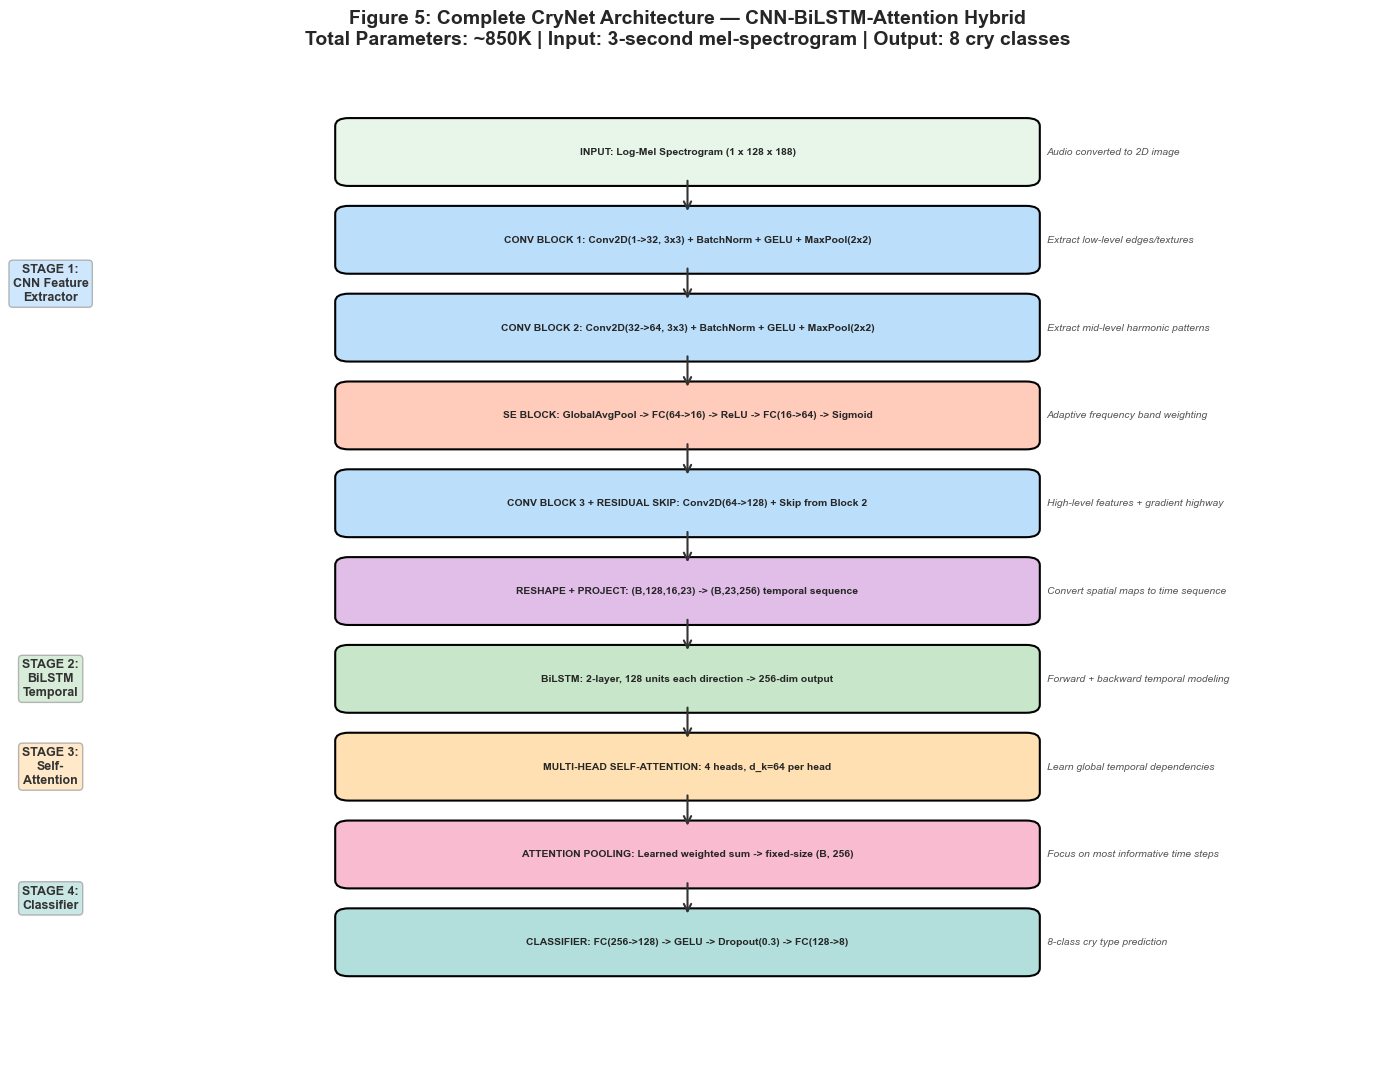

Literature Review Complete!


In [6]:
# ============================================================
# Figure 5: CryNet Architecture Diagram
# ============================================================

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 12)
ax.axis("off")

blocks = [
    (5, 11, 5, 0.65, "INPUT: Log-Mel Spectrogram (1 x 128 x 188)", "#E8F5E9", "Audio converted to 2D image"),
    (5, 9.9, 5, 0.65, "CONV BLOCK 1: Conv2D(1->32, 3x3) + BatchNorm + GELU + MaxPool(2x2)", "#BBDEFB", "Extract low-level edges/textures"),
    (5, 8.8, 5, 0.65, "CONV BLOCK 2: Conv2D(32->64, 3x3) + BatchNorm + GELU + MaxPool(2x2)", "#BBDEFB", "Extract mid-level harmonic patterns"),
    (5, 7.7, 5, 0.65, "SE BLOCK: GlobalAvgPool -> FC(64->16) -> ReLU -> FC(16->64) -> Sigmoid", "#FFCCBC", "Adaptive frequency band weighting"),
    (5, 6.6, 5, 0.65, "CONV BLOCK 3 + RESIDUAL SKIP: Conv2D(64->128) + Skip from Block 2", "#BBDEFB", "High-level features + gradient highway"),
    (5, 5.5, 5, 0.65, "RESHAPE + PROJECT: (B,128,16,23) -> (B,23,256) temporal sequence", "#E1BEE7", "Convert spatial maps to time sequence"),
    (5, 4.4, 5, 0.65, "BiLSTM: 2-layer, 128 units each direction -> 256-dim output", "#C8E6C9", "Forward + backward temporal modeling"),
    (5, 3.3, 5, 0.65, "MULTI-HEAD SELF-ATTENTION: 4 heads, d_k=64 per head", "#FFE0B2", "Learn global temporal dependencies"),
    (5, 2.2, 5, 0.65, "ATTENTION POOLING: Learned weighted sum -> fixed-size (B, 256)", "#F8BBD0", "Focus on most informative time steps"),
    (5, 1.1, 5, 0.65, "CLASSIFIER: FC(256->128) -> GELU -> Dropout(0.3) -> FC(128->8)", "#B2DFDB", "8-class cry type prediction"),
]

for x, y, w, h, text, facecolor, desc in blocks:
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                     boxstyle="round,pad=0.1",
                                     facecolor=facecolor,
                                     edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center", fontsize=7.5, fontweight="bold")
    # Description on the right
    ax.text(x + w/2 + 0.15, y, desc, ha="left", va="center", fontsize=7.5, fontstyle="italic", color="#555")

for i in range(len(blocks)-1):
    y_start = blocks[i][1] - blocks[i][3]/2
    y_end = blocks[i+1][1] + blocks[i+1][3]/2
    ax.annotate("", xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle="->", color="#333", lw=1.5))

# Stage labels on left
stages = [
    (0.3, 9.35, "STAGE 1:\nCNN Feature\nExtractor", "#BBDEFB"),
    (0.3, 4.4, "STAGE 2:\nBiLSTM\nTemporal", "#C8E6C9"),
    (0.3, 3.3, "STAGE 3:\nSelf-\nAttention", "#FFE0B2"),
    (0.3, 1.65, "STAGE 4:\nClassifier", "#B2DFDB"),
]
for x, y, text, color in stages:
    ax.text(x, y, text, fontsize=9, fontweight="bold", color="#333", ha="center", va="center",
            bbox=dict(boxstyle="round", facecolor=color, edgecolor="#999", alpha=0.7))

ax.set_title("Figure 5: Complete CryNet Architecture — CNN-BiLSTM-Attention Hybrid\n"
             "Total Parameters: ~850K | Input: 3-second mel-spectrogram | Output: 8 cry classes",
             fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

print("Literature Review Complete!")